In [1]:
# use holodeck environment

In [1]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [2]:
import holodeck as holo
import holodeck
from holodeck.constants import YR, NWTG, SPLC, GYR, PC, MSOL
from holodeck.galaxy_profiles import NFW
from holodeck import utils
from holodeck.librarian import DEF_NUM_FBINS, DEF_NUM_LOUDEST, DEF_PTA_DUR
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp, quad
import numpy as np
import kalepy as kale
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import os
import la_forge.core as co
from ceffyl.chain_utils import chain_utils
import la_forge.diagnostics as dg
from chainconsumer.chainconsumer import ChainConsumer
from emcee.autocorr import integrated_time

import numpy as np
import matplotlib.pyplot as plt

PINT not installed. PINT or libstempo are required to use par and tim files.


## for GPs

In [ ]:
# nfreqs = 5
# param_space = 'PS_Classic_SIDM_Astro_Extended_Version2'
# space_name = param_space.split(".")
# space_class = holo.librarian.param_spaces_dict[space_name[0]] # /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 498)
# print(space_class)
# # for edges
# pta_dur = holo.librarian.DEF_PTA_DUR # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 363)
# fobs_cents, fobs_edges = utils.pta_freqs(dur=pta_dur*YR, num=nfreqs) # from line 787 from /home/users/sti50/.conda/envs/holodeck_ceffyl_ptmcmc/lib/python3.9/site-packages/holodeck/librarian/lib_tools.py
# fobs_orb_cents = fobs_cents / 2.0
# fobs_orb_edges = fobs_edges / 2.0
# space = space_class() # inspired from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py line 516
# from holodeck.gps import gp_utils
# import pickle, h5py, glob, os
# from pathlib import Path
# frequencies = fobs_cents  # shape: (n_freqs,)
# from holodeck import plot, utils
# # Load 15-year data
# # insert your own path here
# my_path = f'{PROJECT_ROOT}/Data/holodeck_astro_data_luke_kelly/' # added by me
# chain_hdall = co.Core(corepath= my_path + 'freespec_posteriors/freespec_hd_all.core')
# Tspan = DEF_PTA_DUR * YR

# for n_train in [4000, 2000, 8000]:
#     print(n_train)
#     chain_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{n_train}_r2000_f5/gp_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'
#     data = np.loadtxt(chain_path)
#     print('chain shape', data.shape)
#     maxLidx = np.argmax(data[:, -4]) # 4th to last column is log posterior
#     print(f'max log posterior value is: {data[maxLidx, -4]}')
#     maxL = data[maxLidx, :6] # last 4 columns in mcmc chains here are log posterior, and other stuff
#     print("Max Likelihood Array For SIDM:", ", ".join("{:.2f}".format(ml) for ml in maxL))  # respects your .format preference
#     maxL_param_values = maxL.tolist()
#     param_names = ['gsmf_phi0_log10', 'gsmf_mchar0_log10', 'mmb_mamp_log10', 'mmb_scatter_dex', 'vt', 'sigma0_over_m_times_t_age_per_1Gyr']
#     params_maxL = dict(zip(param_names, maxL_param_values))
#     params = params_maxL
#     sam, hard = space.model_for_params(params) # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 302)
#     gwb_for_maxL_params = holo.librarian.lib_tools.run_model(
#         sam, hard,
#         pta_dur=DEF_PTA_DUR, nfreqs=nfreqs, nreals=2000, nloudest=DEF_NUM_LOUDEST,
#         gwb_flag=True, singles_flag=False, details_flag=False, params_flag=False,
#         log=None,
#     )
#     strain_realizations = gwb_for_maxL_params['gwb']  # shape: (n_freqs, n_samples)
#     # Compute statistics
#     strain_median = np.median(strain_realizations, axis=1)
#     # two sigma
#     strain_lower = np.percentile(strain_realizations, 2.5, axis=1)
#     strain_upper = np.percentile(strain_realizations, 97.5, axis=1)
#     print(f'for n_train={n_train}\n')
#     print(f'strain_median = {strain_median}')
#     print(f'strain_lower = {strain_lower}')
#     print(f'strain_upper = {strain_upper}')
#     # GP prediction
#     test_array = maxL
#     GW_var_gp_george_pkl = [Path(chain_path).parents[2] / 'gp_training_output/std.pkl']
#     GW_gp_george_pkl = [Path(chain_path).parents[2] / 'gp_training_output/med.pkl']
#     GW_gp_george = pickle.load(open(GW_gp_george_pkl[0], 'rb'))
#     GW_var_gp_george = pickle.load(open(GW_var_gp_george_pkl[0], 'rb'))
#     # make gaussprob objects
#     spectra = None
#     GW_gp = gp_utils.set_up_predictions(spectra, GW_gp_george)
#     GW_var_gp = gp_utils.set_up_predictions(spectra, GW_var_gp_george)
#     max_spec_sidm_gp, rho_gp, rho_pred_gp = gp_utils.hc_from_gp(GW_gp_george[:nfreqs], GW_gp[:nfreqs],
#                                                     GW_var_gp_george[:nfreqs], GW_var_gp[:nfreqs],
#                                                     #    maxL)
#                                                     test_array)
#     max_spec_sidm_std_gp = 0.5 * np.log(10) * max_spec_sidm_gp * rho_pred_gp[:, 1] # using chatGPT
#     print(f'max_spec_sidm_gp = {max_spec_sidm_gp}')
#     print(f'max_spec_sidm_std_gp = {max_spec_sidm_std_gp}')
#     # plotting
#     plt.loglog(frequencies[0:nfreqs], strain_median[0:nfreqs], color='green', lw=3, label='strain (median) using holodeck')
#     plt.fill_between(frequencies[0:nfreqs], strain_lower[0:nfreqs], strain_upper[0:nfreqs], color='green', alpha=0.3, label='95% holodeck predictive interval')
#     # strain using GPs
#     plt.loglog(fobs_cents[0:nfreqs], max_spec_sidm_gp, color='blue', marker='o', label='Predicted strain (median) using GP')
#     plt.fill_between(fobs_cents[0:nfreqs], max_spec_sidm_gp - 2*max_spec_sidm_std_gp, max_spec_sidm_gp + 2*max_spec_sidm_std_gp, color='blue', alpha=0.3, label='95% GP predictive interval')
#     for ii in range(5):
#         if ii < 6:
#             idx = np.where(chain_hdall(chain_hdall.params[(-64+ii)]) > -9)
#             dd = chain_hdall(chain_hdall.params[(-64+ii)])[idx]
#         else:
#             dd = chain_hdall(chain_hdall.params[(-64+ii)])
#         yy, zz = kale.density(dd, probability=True)
#         hc = (np.sqrt((10**yy)**2 * (12*np.pi**2*frequencies[ii]**3*Tspan)))
#         if ii == 0:
#             plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
#                         side='left', color='k', median=False, line=None, label=r'15yr: HD-w/MP+DP+CURN')
#         elif 0 < ii < 3:
#             plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
#                         side='left', color='k', median=False, line=None)
#         elif 2 < ii < 5:
#             plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.1, 
#                         side='left', color='k', median=False, line=None)
#     plt.xlabel("Frequency [Hz]", fontsize=15)
#     plt.ylabel(r"Characteristic Strain $h_c(f)$", fontsize=15)
#     # plt.xlim(1.5e-9, 3e-8)
#     plt.ylim(3e-16, 5e-14)
#     plt.legend(loc='lower right')
#     # plt.grid(True, which='both', linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()

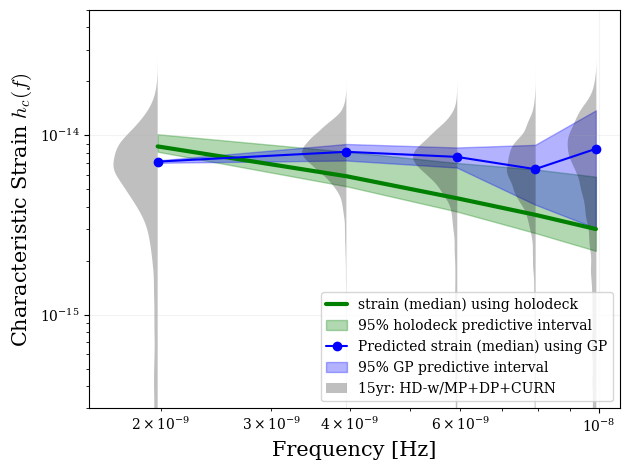

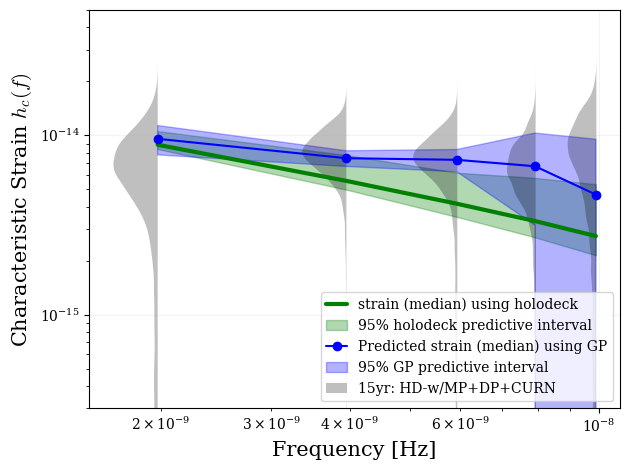

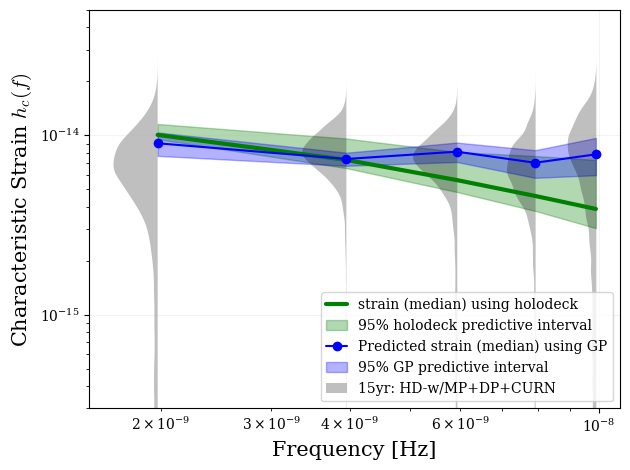

In [8]:
# values from the previous runs

# 2000
strain_median_2000_gp = np.array([8.67493995e-15, 5.91634158e-15, 4.46049459e-15, 3.60544813e-15,
 3.00275761e-15])
strain_lower_2000_gp = np.array([8.10170156e-15, 5.19826636e-15, 3.75986837e-15, 2.85379641e-15,
 2.26859931e-15])
strain_upper_2000_gp = np.array([1.01446416e-14, 8.10097872e-15, 7.01308560e-15, 6.45421952e-15,
 5.87727631e-15])
max_spec_sidm_gp_2000_gp = np.array([7.13856631e-15, 8.09403976e-15, 7.58441755e-15, 6.47972623e-15,
 8.41045400e-15])
max_spec_sidm_std_gp_2000_gp = np.array([5.47032824e-17, 4.28035132e-16, 4.86263380e-16, 1.18537013e-15,
 2.68858678e-15])

# 4000
strain_median_4000_gp = np.array([8.85729960e-15, 5.57102844e-15, 4.15595937e-15, 3.32591323e-15,
 2.74280360e-15])
strain_lower_4000_gp = np.array([8.38290097e-15, 4.97996259e-15, 3.50997960e-15, 2.69815224e-15,
 2.14353817e-15])
strain_upper_4000_gp = np.array([1.05619733e-14, 7.75830989e-15, 6.18940945e-15, 5.79028226e-15,
 5.33560210e-15])
max_spec_sidm_gp_4000_gp = np.array([9.56158745e-15, 7.45447421e-15, 7.30197456e-15, 6.72328668e-15,
 4.67104489e-15])
max_spec_sidm_std_gp_4000_gp = np.array([8.91035939e-16, 3.75173792e-16, 5.17990011e-16, 1.78656864e-15,
 2.42135858e-15])

# 8000
strain_median_8000_gp = np.array([1.00569627e-14, 7.29228219e-15, 5.63057413e-15, 4.59251654e-15,
 3.88566983e-15])
strain_lower_8000_gp = np.array([9.52043831e-15, 6.56292553e-15, 4.83355847e-15, 3.78964411e-15,
 3.03772659e-15])
strain_upper_8000_gp = np.array([1.15742976e-14, 9.59719913e-15, 8.07338910e-15, 7.66925854e-15,
 7.29158624e-15])
max_spec_sidm_gp_8000_gp = np.array([9.03320282e-15, 7.38221216e-15, 8.10886682e-15, 7.03130882e-15,
 7.83416667e-15])
max_spec_sidm_std_gp_8000_gp = np.array([6.75293355e-16, 3.09458538e-16, 5.02577999e-16, 6.17668195e-16,
 9.20569165e-16])


# plotting
def plotting_function_gp(strain_median, strain_lower, strain_upper, max_spec_sidm_gp, max_spec_sidm_std_gp):
    plt.loglog(frequencies[0:nfreqs], strain_median[0:nfreqs], color='green', lw=3, label='strain (median) using holodeck')
    plt.fill_between(frequencies[0:nfreqs], strain_lower[0:nfreqs], strain_upper[0:nfreqs], color='green', alpha=0.3, label='95% holodeck predictive interval')
    # strain using GPs
    plt.loglog(fobs_cents[0:nfreqs], max_spec_sidm_gp, color='blue', marker='o', label='Predicted strain (median) using GP')
    plt.fill_between(fobs_cents[0:nfreqs], max_spec_sidm_gp - 2*max_spec_sidm_std_gp, max_spec_sidm_gp + 2*max_spec_sidm_std_gp, color='blue', alpha=0.3, label='95% GP predictive interval')
    for ii in range(5):
        if ii < 6:
            idx = np.where(chain_hdall(chain_hdall.params[(-64+ii)]) > -9)
            dd = chain_hdall(chain_hdall.params[(-64+ii)])[idx]
        else:
            dd = chain_hdall(chain_hdall.params[(-64+ii)])
        yy, zz = kale.density(dd, probability=True)
        hc = (np.sqrt((10**yy)**2 * (12*np.pi**2*frequencies[ii]**3*Tspan)))
        if ii == 0:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
                        side='left', color='k', median=False, line=None, label=r'15yr: HD-w/MP+DP+CURN')
        elif 0 < ii < 3:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
                        side='left', color='k', median=False, line=None)
        elif 2 < ii < 5:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.1, 
                        side='left', color='k', median=False, line=None)
    plt.xlabel("Frequency [Hz]", fontsize=15)
    plt.ylabel(r"Characteristic Strain $h_c(f)$", fontsize=15)
    # plt.xlim(1.5e-9, 3e-8)
    plt.ylim(3e-16, 5e-14)
    plt.legend(loc='lower right')
    # plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plotting_function_gp(strain_median_2000_gp, strain_lower_2000_gp, strain_upper_2000_gp, max_spec_sidm_gp_2000_gp, max_spec_sidm_std_gp_2000_gp)
plotting_function_gp(strain_median_4000_gp, strain_lower_4000_gp, strain_upper_4000_gp, max_spec_sidm_gp_4000_gp, max_spec_sidm_std_gp_4000_gp)
plotting_function_gp(strain_median_8000_gp, strain_lower_8000_gp, strain_upper_8000_gp, max_spec_sidm_gp_8000_gp, max_spec_sidm_std_gp_8000_gp)

## for NNs

In [7]:
# nfreqs = 5
# param_space = 'PS_Classic_SIDM_Astro_Extended_Version2'
# space_name = param_space.split(".")
# space_class = holo.librarian.param_spaces_dict[space_name[0]] # /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 498)
# print(space_class)
# # for edges
# pta_dur = holo.librarian.DEF_PTA_DUR # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 363)
# fobs_cents, fobs_edges = utils.pta_freqs(dur=pta_dur*YR, num=nfreqs) # from line 787 from /home/users/sti50/.conda/envs/holodeck_ceffyl_ptmcmc/lib/python3.9/site-packages/holodeck/librarian/lib_tools.py
# fobs_orb_cents = fobs_cents / 2.0
# fobs_orb_edges = fobs_edges / 2.0
# space = space_class() # inspired from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py line 516
# from pathlib import Path
# from tensorflow import keras
# import os
# import tensorflow_probability as tfp
# tfpl = tfp.layers
# tfd = tfp.distributions
# frequencies = fobs_cents  # shape: (n_freqs,)
# from holodeck import plot, utils
# # Load 15-year data
# # insert your own path here
# my_path = f'{PROJECT_ROOT}/Data/holodeck_astro_data_luke_kelly/' # added by me
# chain_hdall = co.Core(corepath= my_path + 'freespec_posteriors/freespec_hd_all.core')
# Tspan = DEF_PTA_DUR * YR

# for n_train in [2000, 4000, 8000]:
#     print(n_train)
#     chain_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{n_train}_r2000_f5/nn_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'
#     data = np.loadtxt(chain_path)
#     print('chain shape', data.shape)
#     maxLidx = np.argmax(data[:, -4]) # 4th to last column is log posterior
#     print(f'max log posterior value is: {data[maxLidx, -4]}')
#     maxL = data[maxLidx, :6] # last 4 columns in mcmc chains here are log posterior, and other stuff
#     print("Max Likelihood Array For SIDM:", ", ".join("{:.2f}".format(ml) for ml in maxL))  # respects your .format preference
#     maxL_param_values = maxL.tolist()
#     param_names = ['gsmf_phi0_log10', 'gsmf_mchar0_log10', 'mmb_mamp_log10', 'mmb_scatter_dex', 'vt', 'sigma0_over_m_times_t_age_per_1Gyr']
#     params_maxL = dict(zip(param_names, maxL_param_values))
#     params = params_maxL
#     sam, hard = space.model_for_params(params) # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 302)
#     gwb_for_maxL_params = holo.librarian.lib_tools.run_model(
#         sam, hard,
#         pta_dur=DEF_PTA_DUR, nfreqs=nfreqs, nreals=2000, nloudest=DEF_NUM_LOUDEST,
#         gwb_flag=True, singles_flag=False, details_flag=False, params_flag=False,
#         log=None,
#     )
#     strain_realizations = gwb_for_maxL_params['gwb']  # shape: (n_freqs, n_samples)
#     # Compute statistics
#     strain_median = np.median(strain_realizations, axis=1)
#     # two sigma
#     strain_lower = np.percentile(strain_realizations, 2.5, axis=1)
#     strain_upper = np.percentile(strain_realizations, 97.5, axis=1)
#     print(f'for n_train={n_train}\n')
#     print(f'strain_median = {strain_median}')
#     print(f'strain_lower = {strain_lower}')
#     print(f'strain_upper = {strain_upper}')
#     # NN prediction
#     etac = maxL
#     nn_dir = Path(chain_path).parents[2] / 'nn_training_output'
#     model_median = keras.models.load_model(os.path.join(nn_dir, "nn_model_median.keras"),
#         custom_objects={"DistributionLambda": tfpl.DistributionLambda},
#         compile=False,safe_mode=False)
#     model_std = keras.models.load_model(os.path.join(nn_dir, "nn_model_std.keras"),
#         custom_objects={"DistributionLambda": tfpl.DistributionLambda},
#         compile=False,safe_mode=False)
#     normalization_params = np.load(os.path.join(nn_dir, "normalization_params.npz"))
#     mu_x = normalization_params["mu_x"]
#     std_x = normalization_params["std_x"]
#     mu_y_median = normalization_params["mu_y_median"]
#     std_y_median = normalization_params["std_y_median"]
#     std_y_std = normalization_params["std_y_std"]
#     unnormalized_test_param = etac.reshape(1, len(etac)) # shape (1, 6)
#     normalized_test_param = (unnormalized_test_param - mu_x) / std_x
#     y_pred_dist_median = model_median(normalized_test_param)
#     y_pred_median_nn = y_pred_dist_median.mean()
#     y_pred_median_unc_nn = y_pred_dist_median.stddev()
#     y_pred_dist_std = model_std(normalized_test_param)
#     y_pred_std_nn = y_pred_dist_std.mean()
#     y_pred_std_unc_nn = y_pred_dist_std.stddev()
#     y_pred_total_std_nn = np.sqrt(y_pred_median_unc_nn**2 + y_pred_std_nn**2 + y_pred_std_unc_nn**2)
#     y_pred_total_original_std_nn = y_pred_total_std_nn * std_y_std
#     y_pred_original_median_nn = y_pred_median_nn * std_y_median + mu_y_median
#     max_spec_sidm_nn = 10**(y_pred_original_median_nn.numpy().reshape(5,) / 2)
#     rho_pred = y_pred_total_original_std_nn.reshape(5,)
#     max_spec_sidm_std_nn = 0.5 * np.log(10) * max_spec_sidm_nn * rho_pred # using chatGPT
#     print(f'max_spec_sidm_nn = {max_spec_sidm_nn}')
#     print(f'max_spec_sidm_std_nn = {max_spec_sidm_std_nn}')
#     # plotting
#     plt.loglog(frequencies[0:nfreqs], strain_median[0:nfreqs], color='green', lw=3, label='strain (median) using holodeck')
#     plt.fill_between(frequencies[0:nfreqs], strain_lower[0:nfreqs], strain_upper[0:nfreqs], color='green', alpha=0.3, label='95% holodeck predictive interval')
#     # strain using GPs
#     plt.loglog(fobs_cents[0:nfreqs], max_spec_sidm_nn, color='red', marker='o', label='Predicted strain (median) using NN')
#     plt.fill_between(fobs_cents[0:nfreqs], max_spec_sidm_nn - 2*max_spec_sidm_std_nn, max_spec_sidm_nn + 2*max_spec_sidm_std_nn, color='red', alpha=0.3, label='95% NN predictive interval')
#     for ii in range(5):
#         if ii < 6:
#             idx = np.where(chain_hdall(chain_hdall.params[(-64+ii)]) > -9)
#             dd = chain_hdall(chain_hdall.params[(-64+ii)])[idx]
#         else:
#             dd = chain_hdall(chain_hdall.params[(-64+ii)])
#         yy, zz = kale.density(dd, probability=True)
#         hc = (np.sqrt((10**yy)**2 * (12*np.pi**2*frequencies[ii]**3*Tspan)))
#         if ii == 0:
#             plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
#                         side='left', color='k', median=False, line=None, label=r'15yr: HD-w/MP+DP+CURN')
#         elif 0 < ii < 3:
#             plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
#                         side='left', color='k', median=False, line=None)
#         elif 2 < ii < 5:
#             plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.1, 
#                         side='left', color='k', median=False, line=None)
#     plt.xlabel("Frequency [Hz]", fontsize=15)
#     plt.ylabel(r"Characteristic Strain $h_c(f)$", fontsize=15)
#     # plt.xlim(1.5e-9, 3e-8)
#     plt.ylim(3e-16, 5e-14)
#     plt.legend(loc='lower right')
#     # plt.grid(True, which='both', linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()

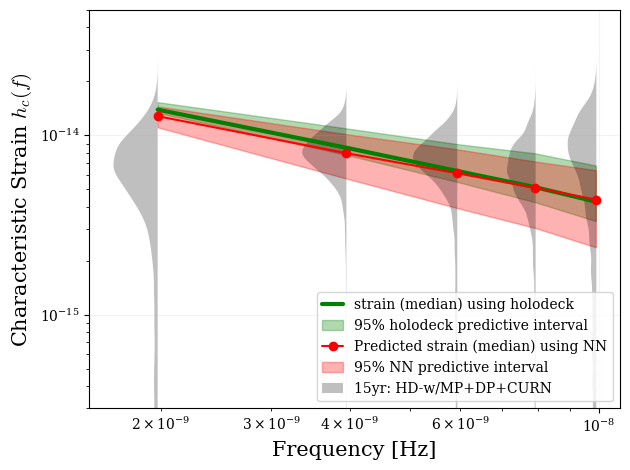

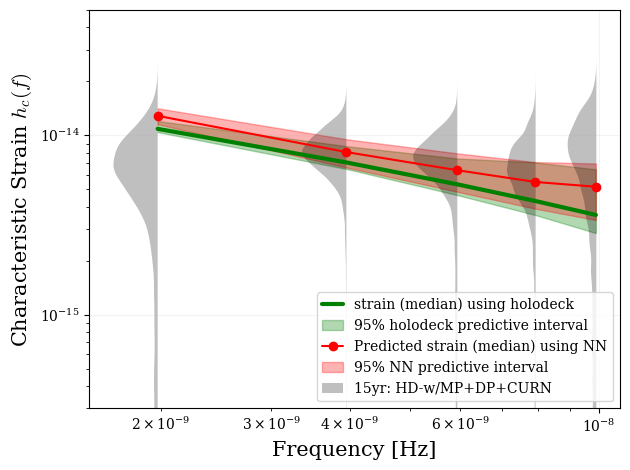

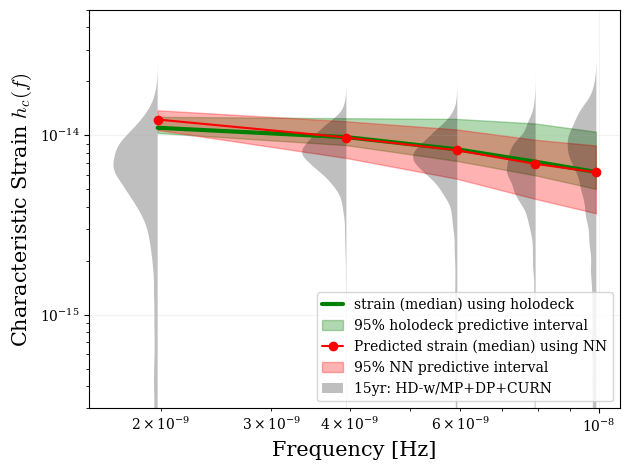

In [11]:
# values from the previous runs

# 2000
strain_median_2000_nn = np.array([1.39100186e-14, 8.52795793e-15, 6.33380327e-15, 5.13876897e-15,
 4.26853761e-15])
strain_lower_2000_nn = np.array([1.33532341e-14, 7.78192791e-15, 5.50751467e-15, 4.23946987e-15,
 3.32515373e-15])
strain_upper_2000_nn = np.array([1.53208180e-14, 1.09348789e-14, 8.94449020e-15, 7.93819233e-15,
 6.78282176e-15])
max_spec_sidm_nn_2000_nn = np.array([1.2790958e-14, 7.9477771e-15, 6.1498581e-15, 5.0949167e-15, 4.3850777e-15])
max_spec_sidm_std_nn_2000_nn = np.array([8.52052644e-16, 1.10286341e-15, 1.10709641e-15, 1.02521346e-15,
 1.00500940e-15])

# 4000
strain_median_4000_nn = np.array([1.08687611e-14, 7.05893597e-15, 5.33711087e-15, 4.30543323e-15,
 3.59790231e-15])
strain_lower_4000_nn = np.array([1.04240266e-14, 6.49489985e-15, 4.65179435e-15, 3.59822197e-15,
 2.85101124e-15])
strain_upper_4000_nn = np.array([1.20263597e-14, 8.70315544e-15, 7.43306967e-15, 7.06304646e-15,
 6.46368587e-15])
max_spec_sidm_nn_4000_nn = np.array([1.2845142e-14, 8.0658933e-15, 6.3969796e-15, 5.4973370e-15, 5.1681376e-15])
max_spec_sidm_std_nn_4000_nn = np.array([6.55406314e-16, 7.23289276e-16, 7.72254432e-16, 7.97650062e-16,
 8.99072233e-16])

# 8000
strain_median_8000_nn = np.array([1.10200937e-14, 9.77262742e-15, 8.36098230e-15, 7.13304186e-15,
 6.24832279e-15])
strain_lower_8000_nn = np.array([1.03081684e-14, 8.81281888e-15, 7.19989167e-15, 5.98665674e-15,
 5.02514026e-15])
strain_upper_8000_nn = np.array([1.26810681e-14, 1.24620964e-14, 1.23481764e-14, 1.16477783e-14,
 1.04772593e-14])
max_spec_sidm_nn_8000_nn = np.array([1.2254160e-14, 9.7226651e-15, 8.2569839e-15, 6.9356832e-15, 6.2279334e-15])
max_spec_sidm_std_nn_8000_nn = np.array([7.71384874e-16, 1.12506163e-15, 1.26465930e-15, 1.25525020e-15,
 1.27594339e-15])


# plotting
def plotting_function_nn(strain_median, strain_lower, strain_upper, max_spec_sidm_gp, max_spec_sidm_std_gp):
    plt.loglog(frequencies[0:nfreqs], strain_median[0:nfreqs], color='green', lw=3, label='strain (median) using holodeck')
    plt.fill_between(frequencies[0:nfreqs], strain_lower[0:nfreqs], strain_upper[0:nfreqs], color='green', alpha=0.3, label='95% holodeck predictive interval')
    # strain using GPs
    plt.loglog(fobs_cents[0:nfreqs], max_spec_sidm_gp, color='red', marker='o', label='Predicted strain (median) using NN')
    plt.fill_between(fobs_cents[0:nfreqs], max_spec_sidm_gp - 2*max_spec_sidm_std_gp, max_spec_sidm_gp + 2*max_spec_sidm_std_gp, color='red', alpha=0.3, label='95% NN predictive interval')
    for ii in range(5):
        if ii < 6:
            idx = np.where(chain_hdall(chain_hdall.params[(-64+ii)]) > -9)
            dd = chain_hdall(chain_hdall.params[(-64+ii)])[idx]
        else:
            dd = chain_hdall(chain_hdall.params[(-64+ii)])
        yy, zz = kale.density(dd, probability=True)
        hc = (np.sqrt((10**yy)**2 * (12*np.pi**2*frequencies[ii]**3*Tspan)))
        if ii == 0:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
                        side='left', color='k', median=False, line=None, label=r'15yr: HD-w/MP+DP+CURN')
        elif 0 < ii < 3:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
                        side='left', color='k', median=False, line=None)
        elif 2 < ii < 5:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.1, 
                        side='left', color='k', median=False, line=None)
    plt.xlabel("Frequency [Hz]", fontsize=15)
    plt.ylabel(r"Characteristic Strain $h_c(f)$", fontsize=15)
    # plt.xlim(1.5e-9, 3e-8)
    plt.ylim(3e-16, 5e-14)
    plt.legend(loc='lower right')
    # plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plotting_function_nn(strain_median_2000_nn, strain_lower_2000_nn, strain_upper_2000_nn, max_spec_sidm_nn_2000_nn, max_spec_sidm_std_nn_2000_nn)
plotting_function_nn(strain_median_4000_nn, strain_lower_4000_nn, strain_upper_4000_nn, max_spec_sidm_nn_4000_nn, max_spec_sidm_std_nn_4000_nn)
plotting_function_nn(strain_median_8000_nn, strain_lower_8000_nn, strain_upper_8000_nn, max_spec_sidm_nn_8000_nn, max_spec_sidm_std_nn_8000_nn)